# 1. To same dimension then MMD

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import pdist

from scipy.linalg import orthogonal_procrustes


In [2]:
feature_sizes = [10, 20, 24, 28, 32, 36, 40, 44, 48, 52]

file_paths = {
    d: f"train_df_feature{d}.csv"
    for d in feature_sizes
}

In [3]:
train_dfs = {
    d: pd.read_csv(path)
    for d, path in file_paths.items()
}

for d, df in train_dfs.items():
    print(
        f"{d} features:",
        df.shape,
        df.columns[:5].tolist(),
        "...",
        df.columns[-3:].tolist()
    )

10 features: (10000, 12) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_10', 'label', 'id']
20 features: (10000, 22) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_20', 'label', 'id']
24 features: (10000, 26) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_24', 'label', 'id']
28 features: (10000, 30) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_28', 'label', 'id']
32 features: (10000, 34) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_32', 'label', 'id']
36 features: (10000, 38) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_36', 'label', 'id']
40 features: (10000, 42) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_40', 'label', 'id']
44 features: (10000, 46) ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'] ... ['feature_44', 'label', 'id']


In [4]:
def get_feature_matrix(df):
    feature_cols = [
        col for col in df.columns
        if col.startswith("feature_")
    ]

    feature_cols = sorted(
        feature_cols,
        key=lambda col: int(col.split("_")[1])
    )

    return df[feature_cols].to_numpy(dtype=np.float64)


X_settings = {
    d: get_feature_matrix(df)
    for d, df in train_dfs.items()
}

for d, X in X_settings.items():
    print(d, X.shape)

10 (10000, 10)
20 (10000, 20)
24 (10000, 24)
28 (10000, 28)
32 (10000, 32)
36 (10000, 36)
40 (10000, 40)
44 (10000, 44)
48 (10000, 48)
52 (10000, 52)


In [5]:
baseline_df = train_dfs[10]

for d in feature_sizes[1:]:
    current_df = train_dfs[d]

    if "id" in baseline_df.columns and "id" in current_df.columns:
        assert np.array_equal(
            baseline_df["id"].to_numpy(),
            current_df["id"].to_numpy()
        ), f"ID order differs for feature setting {d}"

    if "label" in baseline_df.columns and "label" in current_df.columns:
        assert np.array_equal(
            baseline_df["label"].to_numpy(),
            current_df["label"].to_numpy()
        ), f"Label order differs for feature setting {d}"

print("All feature settings contain the same samples.")

All feature settings contain the same samples.


# MMD

In [6]:
def estimate_gamma(X):
    """
    Estimate one RBF gamma value using the median heuristic.
    """
    squared_distances = pdist(X, metric="sqeuclidean")
    positive_distances = squared_distances[squared_distances > 0]

    if len(positive_distances) == 0:
        raise ValueError("All pairwise distances are zero.")

    median_squared_distance = np.median(positive_distances)

    return 1.0 / median_squared_distance

In [7]:
def rbf_mmd_squared(X, Y, gamma):
    """
    Biased empirical squared MMD using an RBF kernel.
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    if X.shape[1] != Y.shape[1]:
        raise ValueError(
            f"MMD requires equal dimensions, but received "
            f"{X.shape[1]} and {Y.shape[1]}."
        )

    K_xx = rbf_kernel(X, X, gamma=gamma)
    K_yy = rbf_kernel(Y, Y, gamma=gamma)
    K_xy = rbf_kernel(X, Y, gamma=gamma)

    value = (
        K_xx.mean()
        + K_yy.mean()
        - 2.0 * K_xy.mean()
    )

    return max(float(value), 0.0)

In [8]:
rng = np.random.default_rng(42)

mmd_sample_size = 10000

sample_indices = rng.choice(
    X_settings[10].shape[0],
    size=mmd_sample_size,
    replace=False
)

# 1.1 Padding, then we do direct MMD

In [9]:
max_dim = max(feature_sizes)
print(max_dim)

full_scaler = StandardScaler()
full_scaler.fit(X_settings[max_dim])

52


StandardScaler()

In [10]:
def standardise_and_pad(X, scaler, max_dim):
    n_samples, current_dim = X.shape

    if current_dim > max_dim:
        raise ValueError("Input dimension exceeds max_dim.")

    X_padded = np.zeros(
        (n_samples, max_dim),
        dtype=np.float64
    )

    X_padded[:, :current_dim] = (
        X - scaler.mean_[:current_dim]
    ) / scaler.scale_[:current_dim]

    return X_padded

In [11]:
X_padded = {
    d: standardise_and_pad(
        X_settings[d],
        scaler=full_scaler,
        max_dim=max_dim
    )
    for d in feature_sizes
}

for d, X in X_padded.items():
    print(d, X.shape)

10 (10000, 52)
20 (10000, 52)
24 (10000, 52)
28 (10000, 52)
32 (10000, 52)
36 (10000, 52)
40 (10000, 52)
44 (10000, 52)
48 (10000, 52)
52 (10000, 52)


In [12]:
padded_baseline = X_padded[10][sample_indices]

gamma_padded = estimate_gamma(padded_baseline)

print("Padding gamma:", gamma_padded)

Padding gamma: 0.05557535090741599


In [13]:
padding_results = []

for d in feature_sizes:
    current = X_padded[d][sample_indices]

    mmd2 = rbf_mmd_squared(
        padded_baseline,
        current,
        gamma=gamma_padded
    )

    padding_results.append({
        "Features": d,
        "Padding_MMD2": mmd2
    })

padding_mmd_df = pd.DataFrame(padding_results)

print(padding_mmd_df)

   Features  Padding_MMD2
0        10      0.000000
1        20      0.071413
2        24      0.111090
3        28      0.149753
4        32      0.185451
5        36      0.217329
6        40      0.245035
7        44      0.268969
8        48      0.288977
9        52      0.305676


# 1.2 Informative Feature Only then MMD

In [14]:
informative_dim = 10

X_informative = {
    d: X_settings[d][:, :informative_dim]
    for d in feature_sizes
}

In [15]:
informative_scaler = StandardScaler()

baseline_informative_scaled = informative_scaler.fit_transform(
    X_informative[10]
)

X_informative_scaled = {
    d: informative_scaler.transform(X_informative[d])
    for d in feature_sizes
}

In [16]:
informative_baseline = X_informative_scaled[10][sample_indices]

gamma_informative = estimate_gamma(informative_baseline)

print("Informative gamma:", gamma_informative)

Informative gamma: 0.05557535090741599


In [17]:
informative_results = []

for d in feature_sizes:
    current = X_informative_scaled[d][sample_indices]

    mmd2 = rbf_mmd_squared(
        informative_baseline,
        current,
        gamma=gamma_informative
    )

    informative_results.append({
        "Features": d,
        "Informative_MMD2": mmd2
    })

informative_mmd_df = pd.DataFrame(informative_results)

print(informative_mmd_df)

   Features  Informative_MMD2
0        10               0.0
1        20               0.0
2        24               0.0
3        28               0.0
4        32               0.0
5        36               0.0
6        40               0.0
7        44               0.0
8        48               0.0
9        52               0.0


# 1.3 Pad then PCA then MMD

In [18]:
max_dim = 52
pca_dim = 10

X_full = X_settings[max_dim]

full_scaler = StandardScaler()
X_full_scaled = full_scaler.fit_transform(X_full)

In [19]:
def standardise_and_pad(X, scaler, max_dim):
    """
    Transform an unequal-dimensional feature matrix into the common
    max-dimensional standardised space.

    Missing appended dimensions are set to zero, corresponding to
    their mean under the scaler fitted on the full dataset.
    """
    X = np.asarray(X, dtype=np.float64)

    n_samples, current_dim = X.shape

    if current_dim > max_dim:
        raise ValueError(
            f"Input has {current_dim} columns, exceeding max_dim={max_dim}."
        )

    X_common = np.zeros(
        (n_samples, max_dim),
        dtype=np.float64
    )

    X_common[:, :current_dim] = (
        X - scaler.mean_[:current_dim]
    ) / scaler.scale_[:current_dim]

    return X_common

In [20]:
X_common = {
    d: standardise_and_pad(
        X_settings[d],
        scaler=full_scaler,
        max_dim=max_dim
    )
    for d in feature_sizes
}

for d, X in X_common.items():
    print(d, X.shape)

10 (10000, 52)
20 (10000, 52)
24 (10000, 52)
28 (10000, 52)
32 (10000, 52)
36 (10000, 52)
40 (10000, 52)
44 (10000, 52)
48 (10000, 52)
52 (10000, 52)


In [21]:
shared_pca = PCA(
    n_components=pca_dim,
    random_state=42
)

shared_pca.fit(X_full_scaled)

print(
    "Explained variance retained:",
    shared_pca.explained_variance_ratio_.sum()
)

Explained variance retained: 0.2576437332623434


In [22]:
X_shared_pca = {
    d: shared_pca.transform(X_common[d])
    for d in feature_sizes
}

for d, X in X_shared_pca.items():
    print(d, X.shape)

10 (10000, 10)
20 (10000, 10)
24 (10000, 10)
28 (10000, 10)
32 (10000, 10)
36 (10000, 10)
40 (10000, 10)
44 (10000, 10)
48 (10000, 10)
52 (10000, 10)


In [23]:
baseline_pca = X_shared_pca[10][sample_indices]

gamma_shared_pca = estimate_gamma(baseline_pca)

print("Shared PCA gamma:", gamma_shared_pca)

Shared PCA gamma: 0.10316288392886001


In [24]:
shared_pca_results = []

for d in feature_sizes:
    current_pca = X_shared_pca[d][sample_indices]

    mmd2 = rbf_mmd_squared(
        baseline_pca,
        current_pca,
        gamma=gamma_shared_pca
    )

    shared_pca_results.append({
        "Features": d,
        "Shared_PCA_MMD2": mmd2
    })

shared_pca_mmd_df = pd.DataFrame(shared_pca_results)

print(shared_pca_mmd_df)

   Features  Shared_PCA_MMD2
0        10         0.000000
1        20         0.011071
2        24         0.022663
3        28         0.028911
4        32         0.040877
5        36         0.047979
6        40         0.063034
7        44         0.075495
8        48         0.088288
9        52         0.106779


In [25]:
combined_mmd_df = (
    padding_mmd_df
    .merge(informative_mmd_df, on="Features")
    .merge(shared_pca_mmd_df, on="Features")
)

print(combined_mmd_df)

   Features  Padding_MMD2  Informative_MMD2  Shared_PCA_MMD2
0        10      0.000000               0.0         0.000000
1        20      0.071413               0.0         0.011071
2        24      0.111090               0.0         0.022663
3        28      0.149753               0.0         0.028911
4        32      0.185451               0.0         0.040877
5        36      0.217329               0.0         0.047979
6        40      0.245035               0.0         0.063034
7        44      0.268969               0.0         0.075495
8        48      0.288977               0.0         0.088288
9        52      0.305676               0.0         0.106779


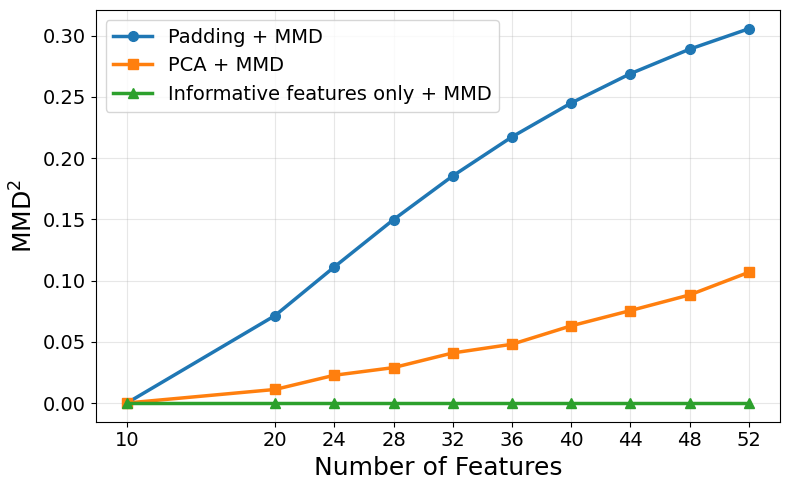

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    combined_mmd_df["Features"],
    combined_mmd_df["Padding_MMD2"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Padding + MMD"
)

plt.plot(
    combined_mmd_df["Features"],
    combined_mmd_df["Shared_PCA_MMD2"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="PCA + MMD"
)

plt.plot(
    combined_mmd_df["Features"],
    combined_mmd_df["Informative_MMD2"],
    marker="^",
    linewidth=2.5,
    markersize=7,
    label="Informative features only + MMD"
)

plt.xlabel("Number of Features", fontsize=18)
plt.ylabel(r"$\mathrm{MMD}^2$", fontsize=18)

plt.xticks(
    combined_mmd_df["Features"],
    fontsize=14
)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Feature_Dimensionality_MMD_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()